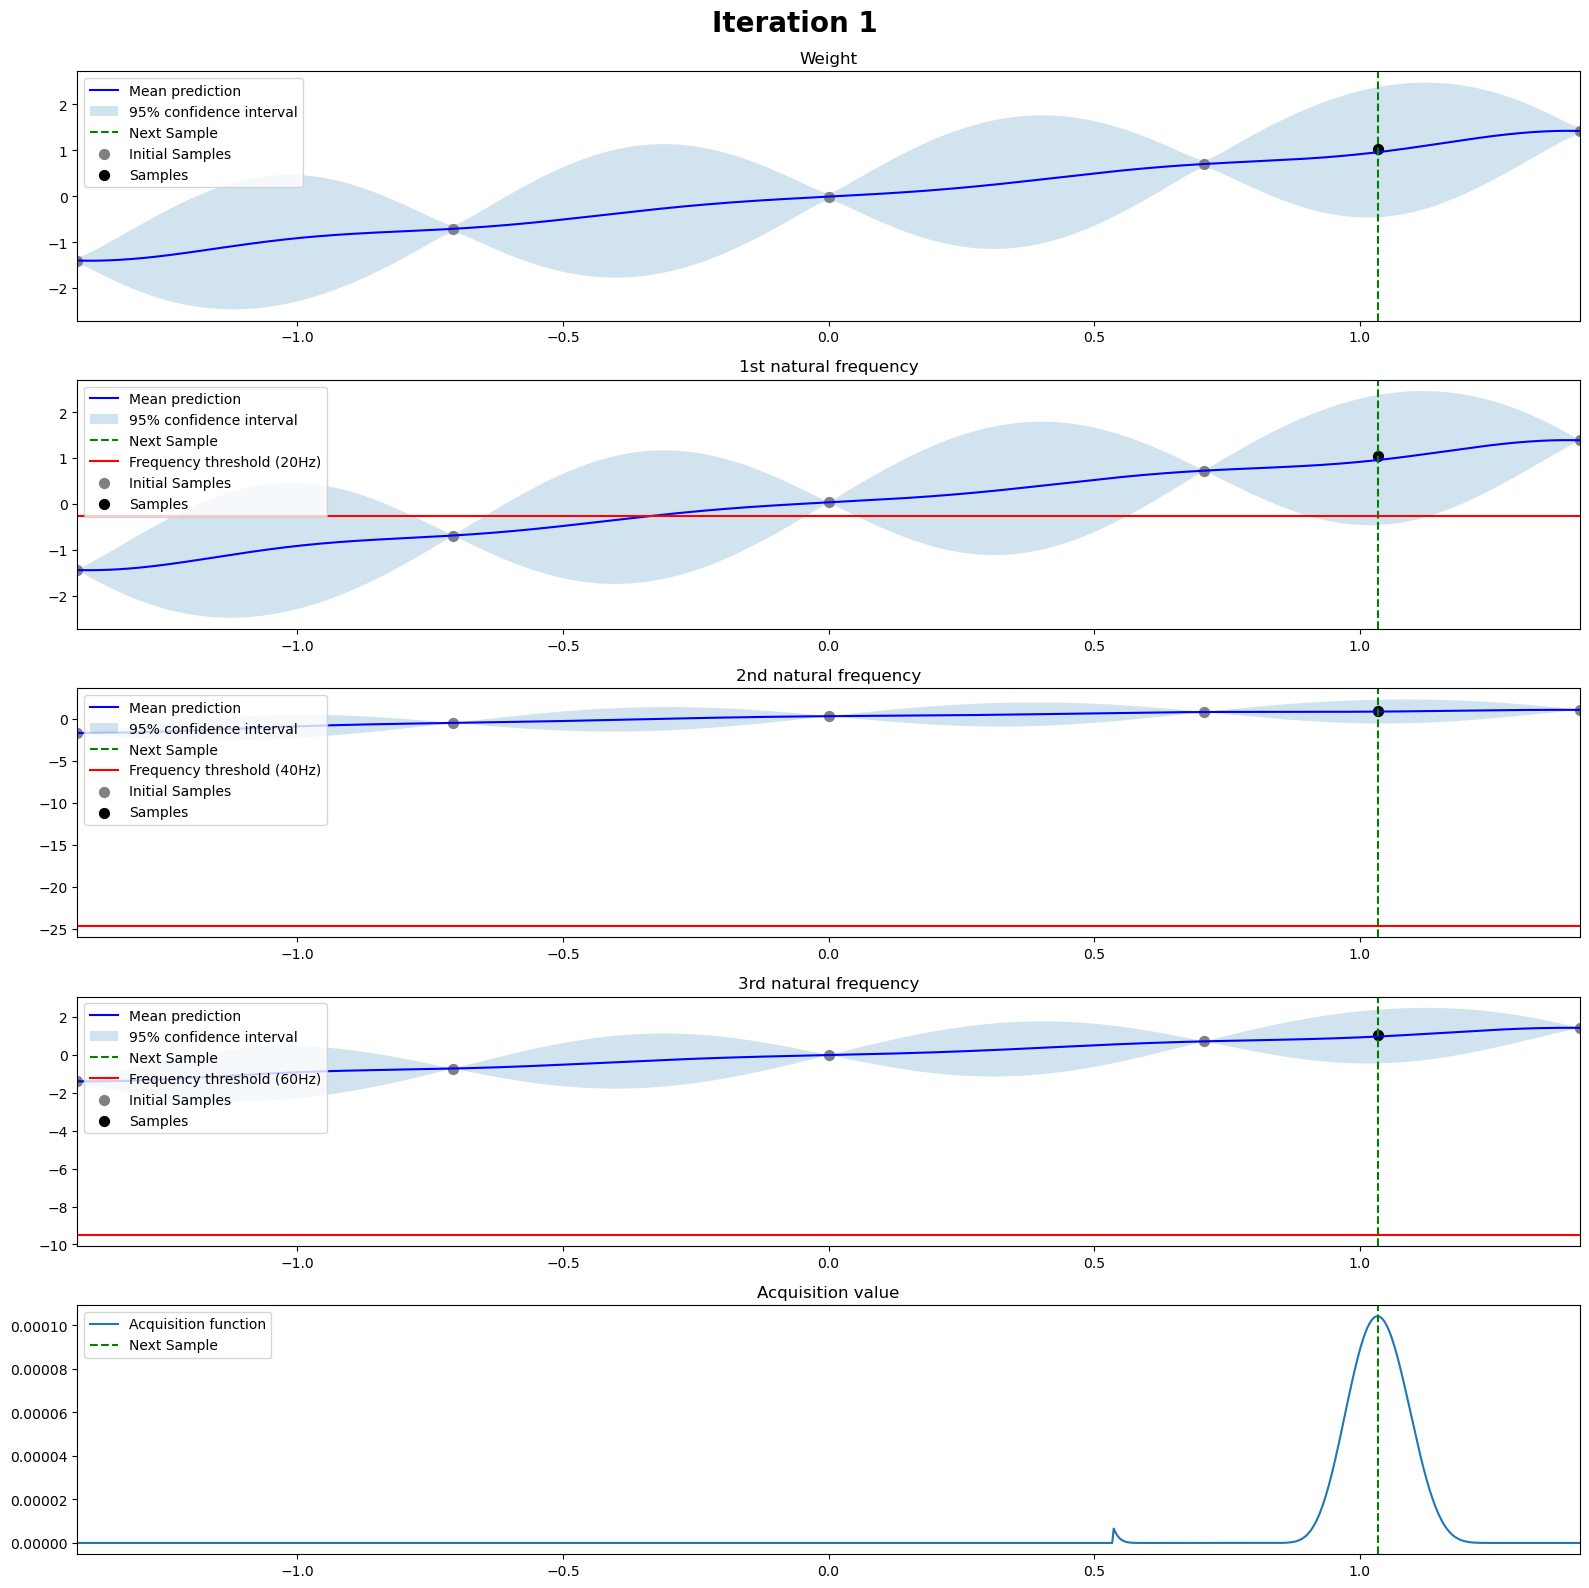

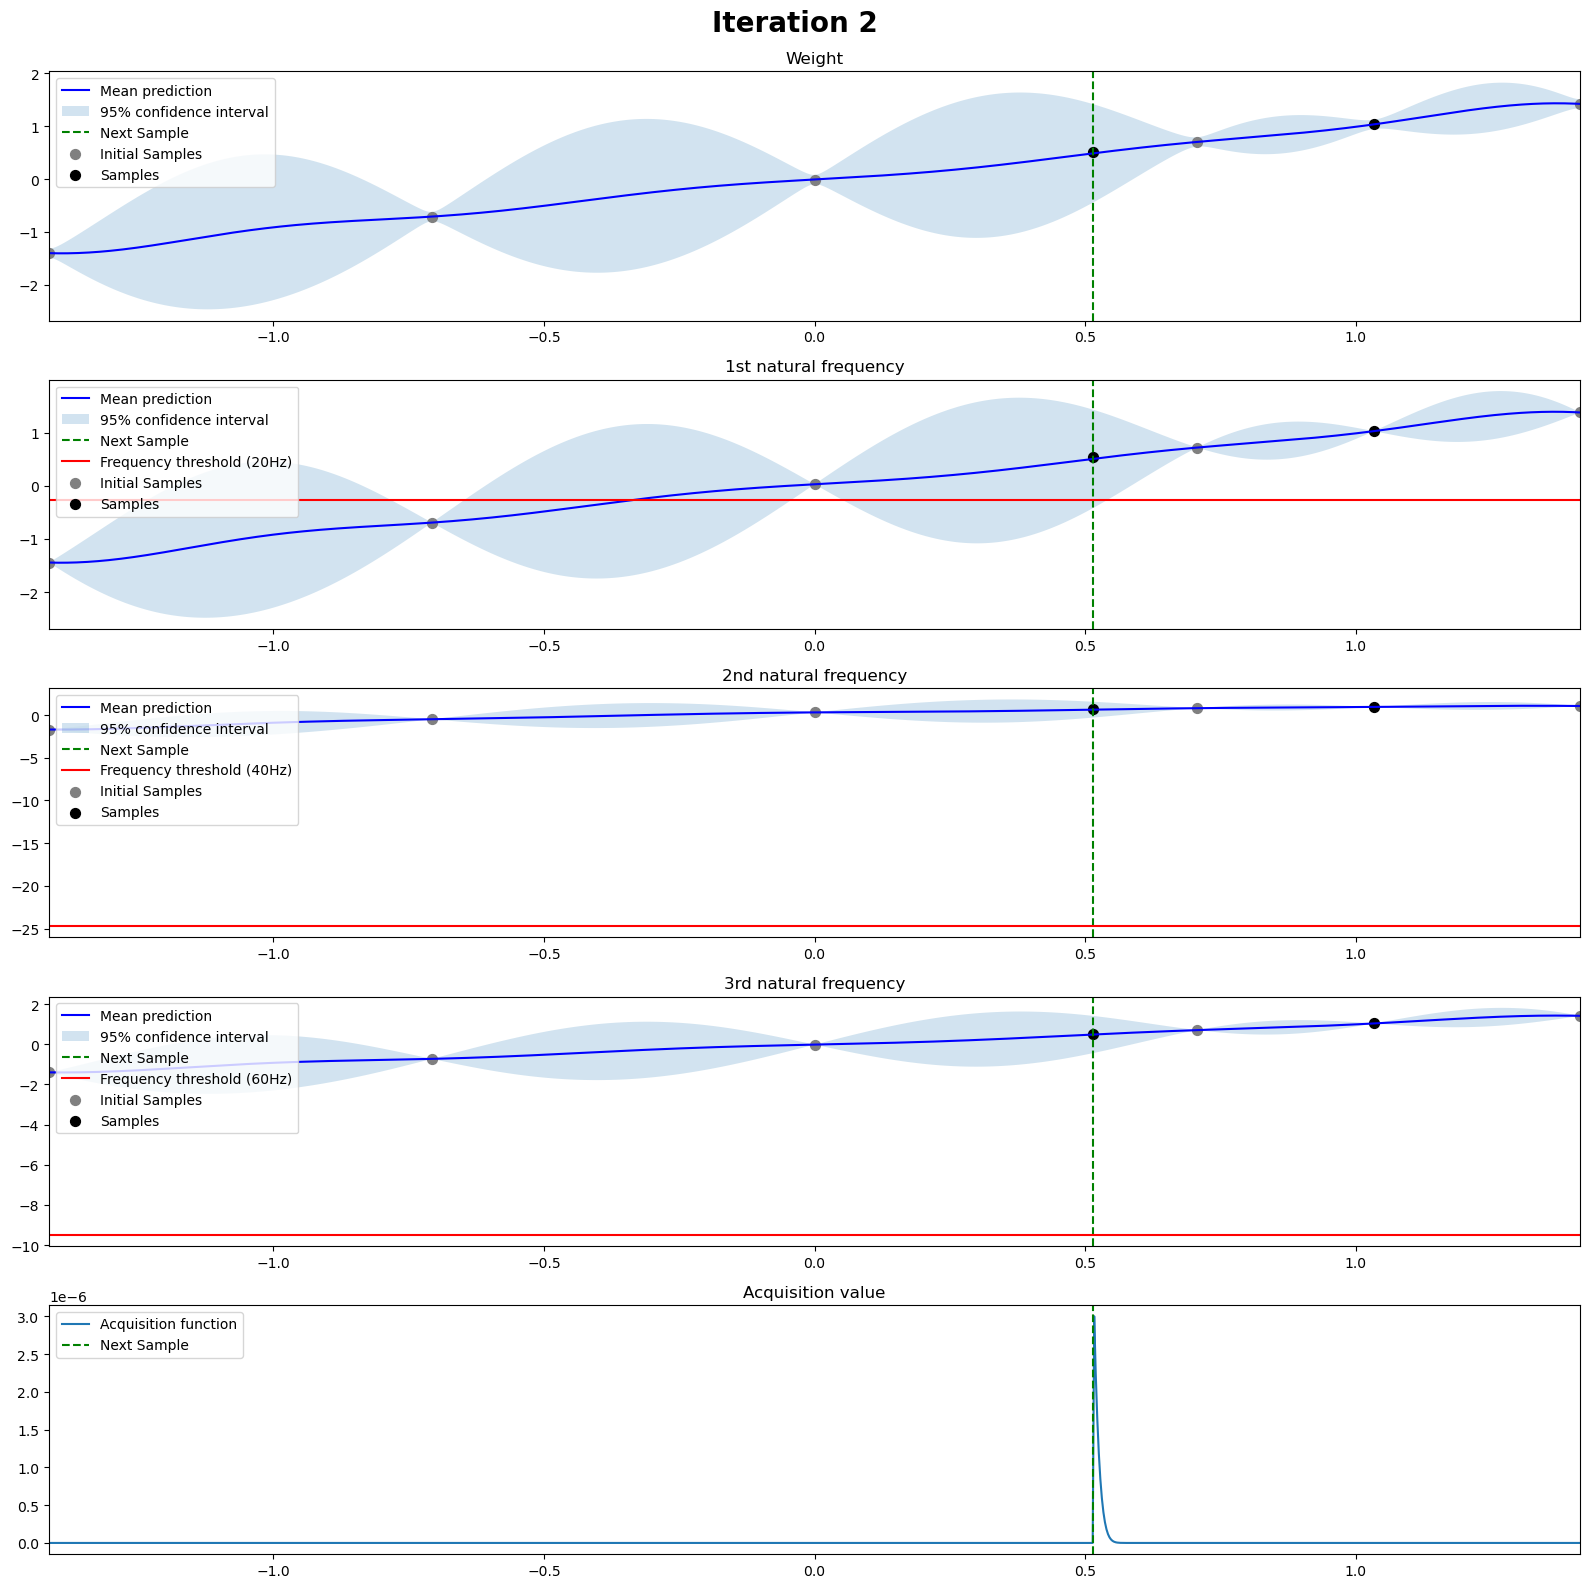

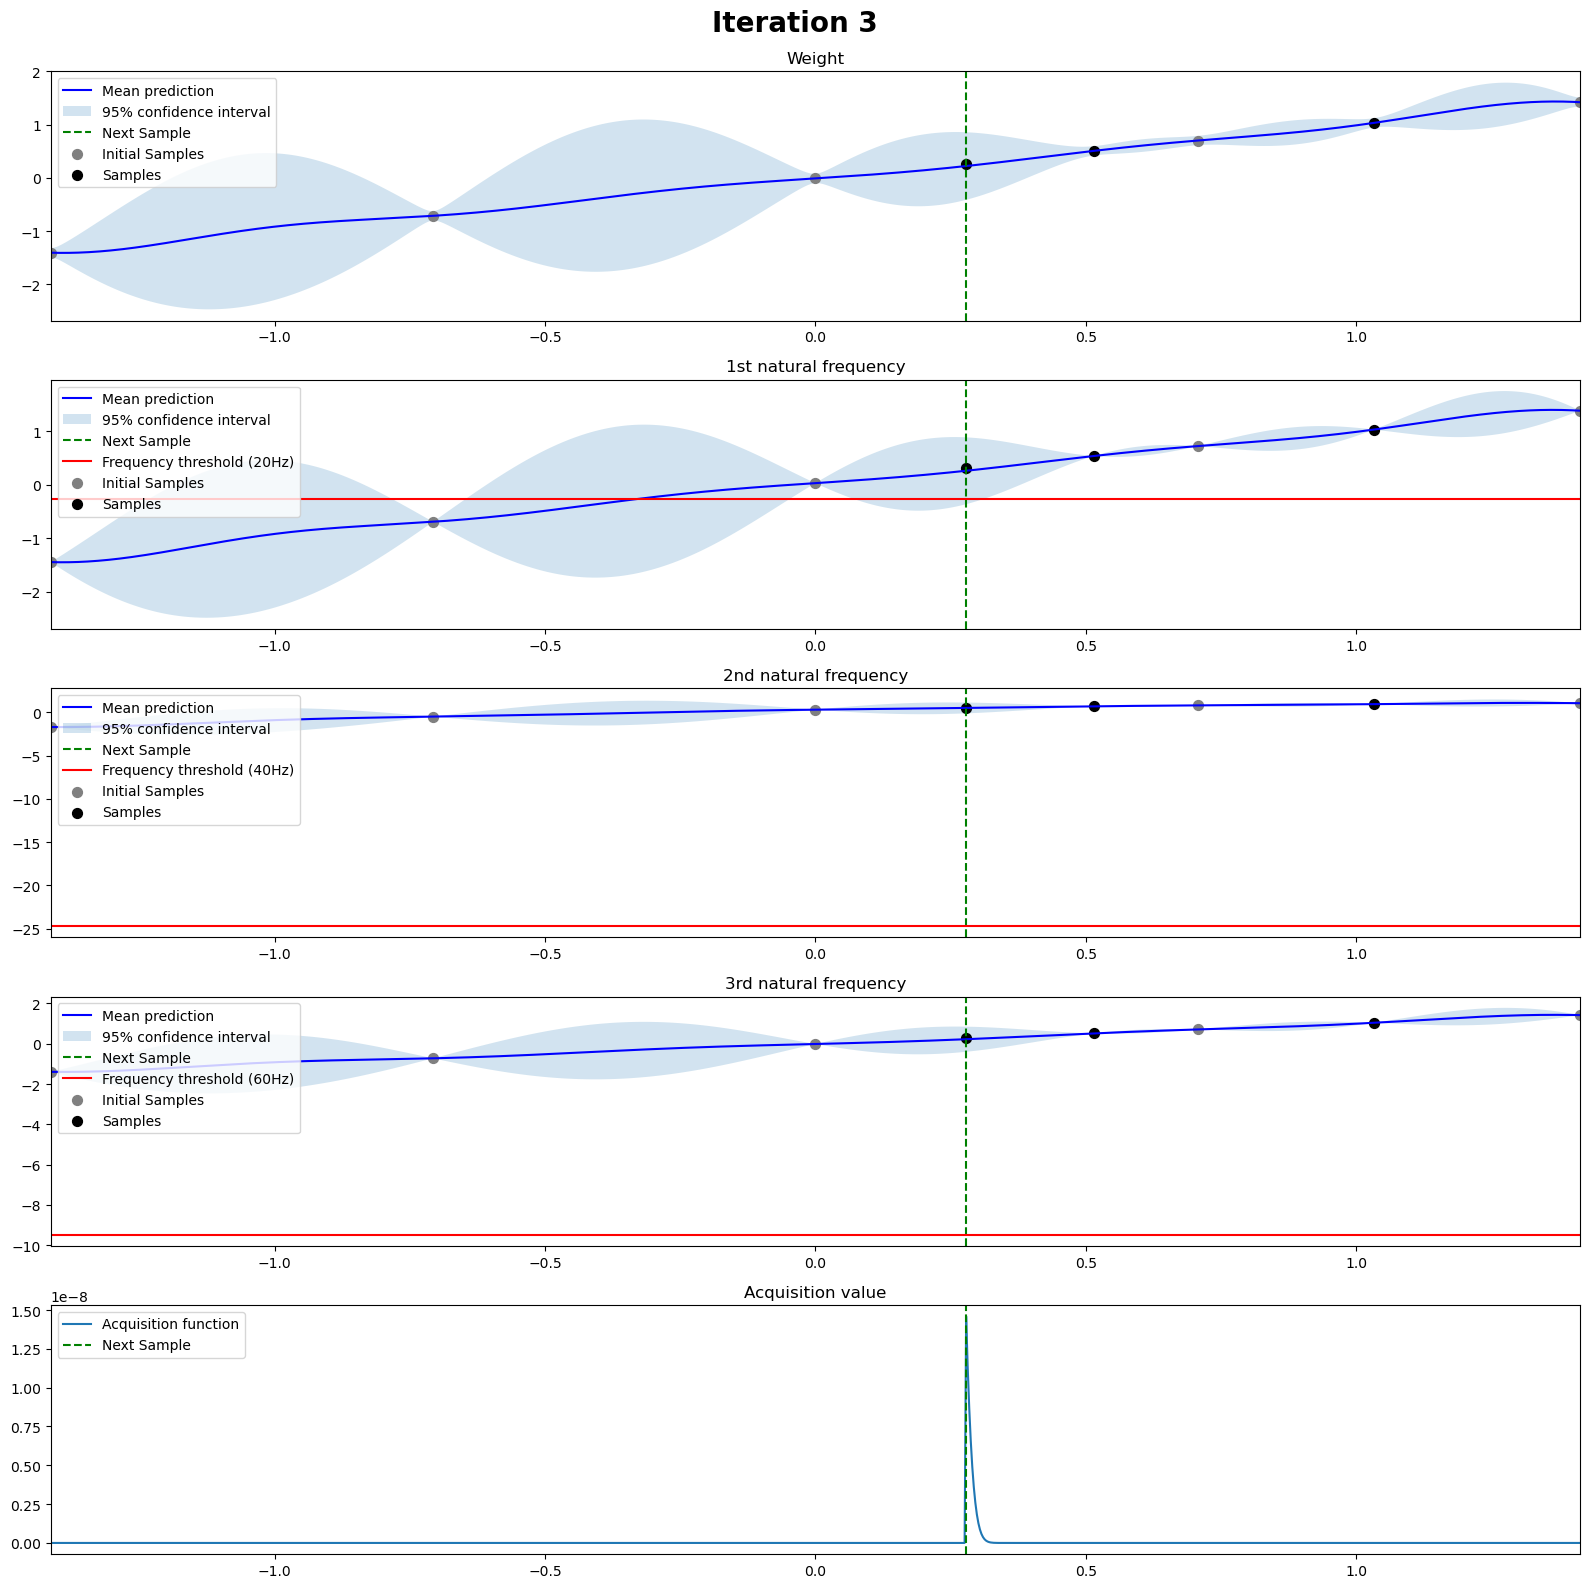

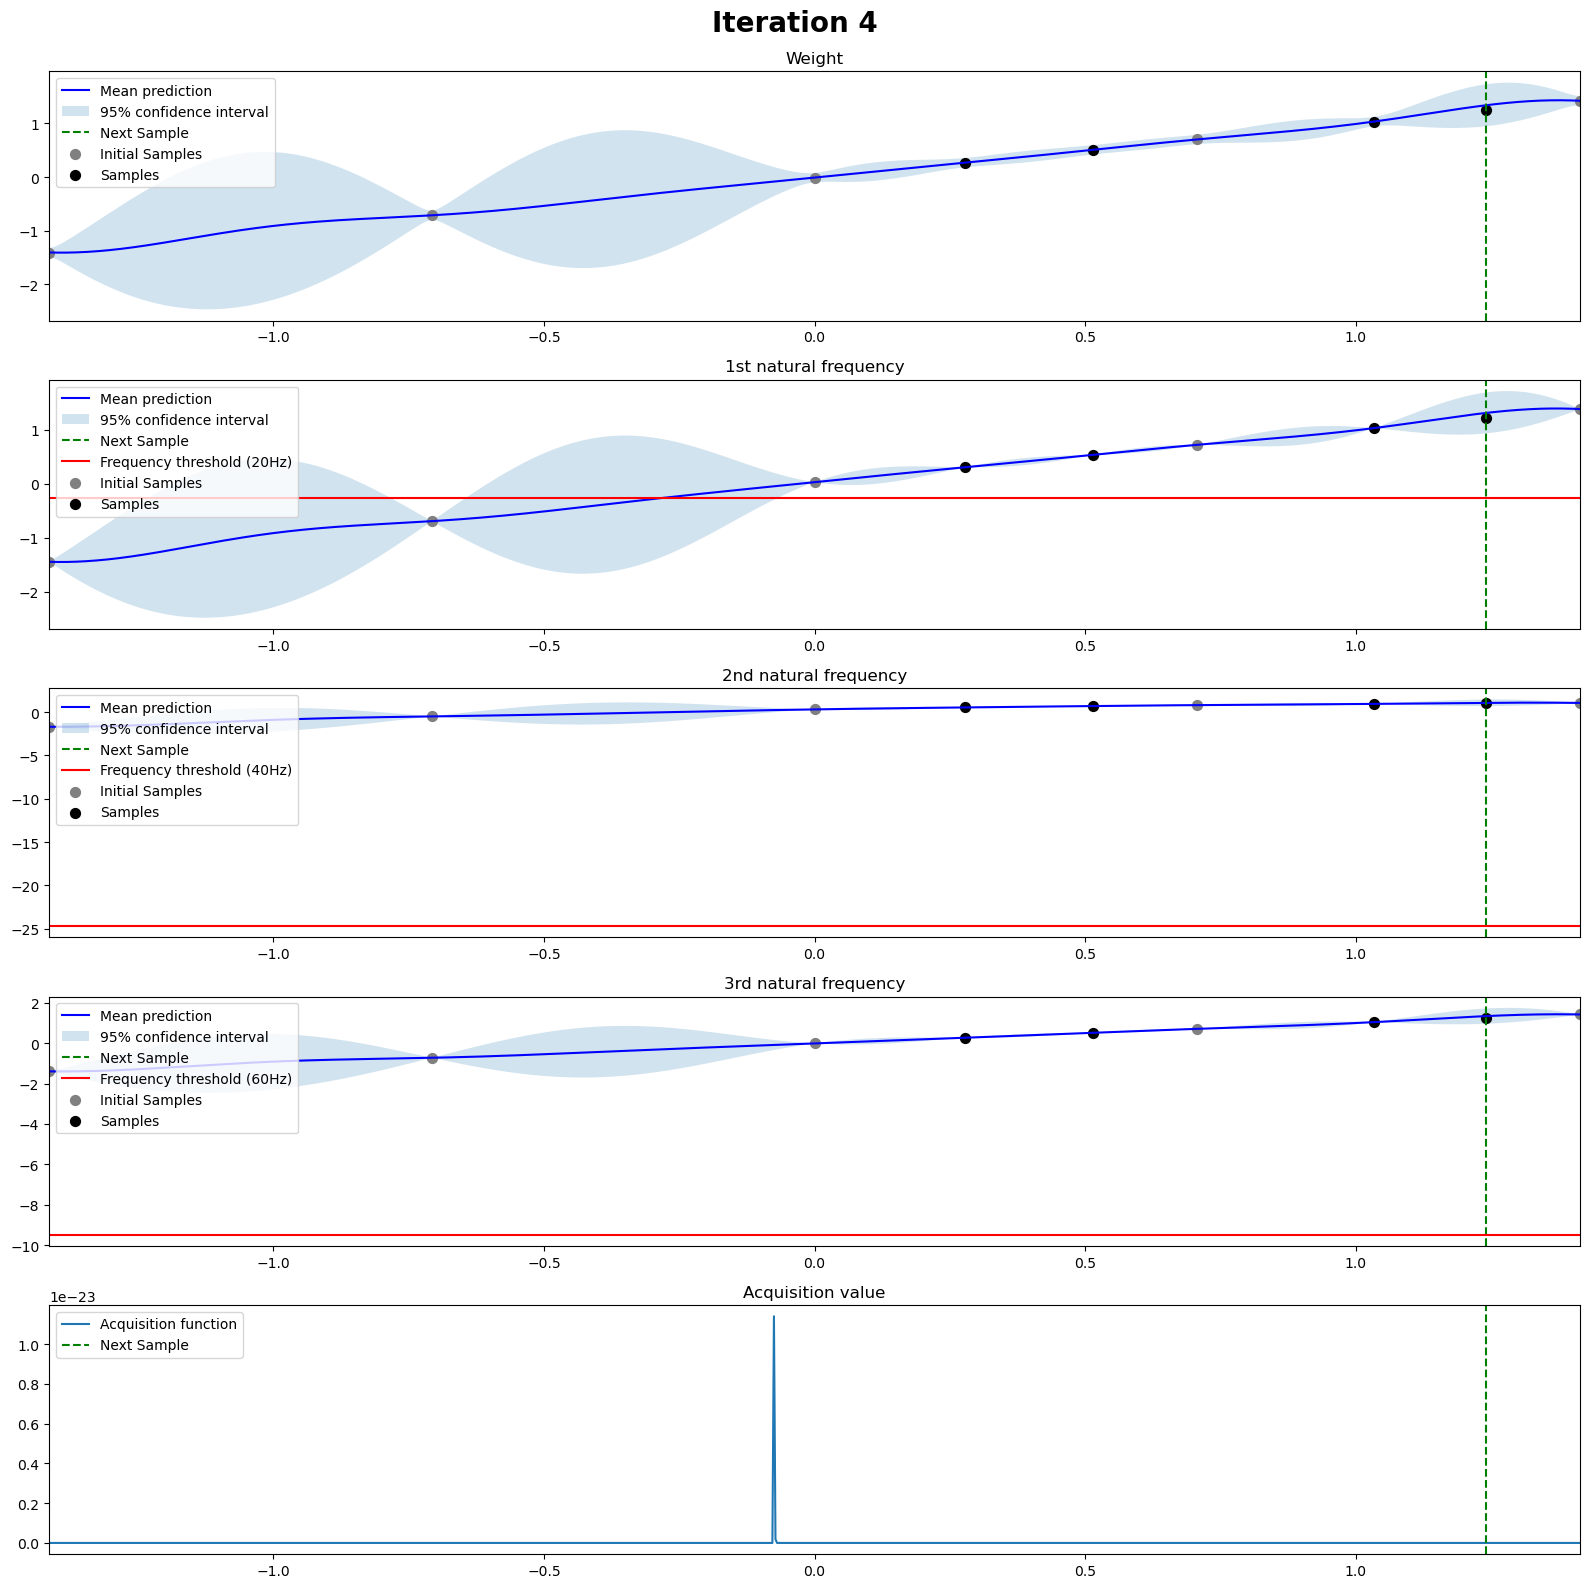

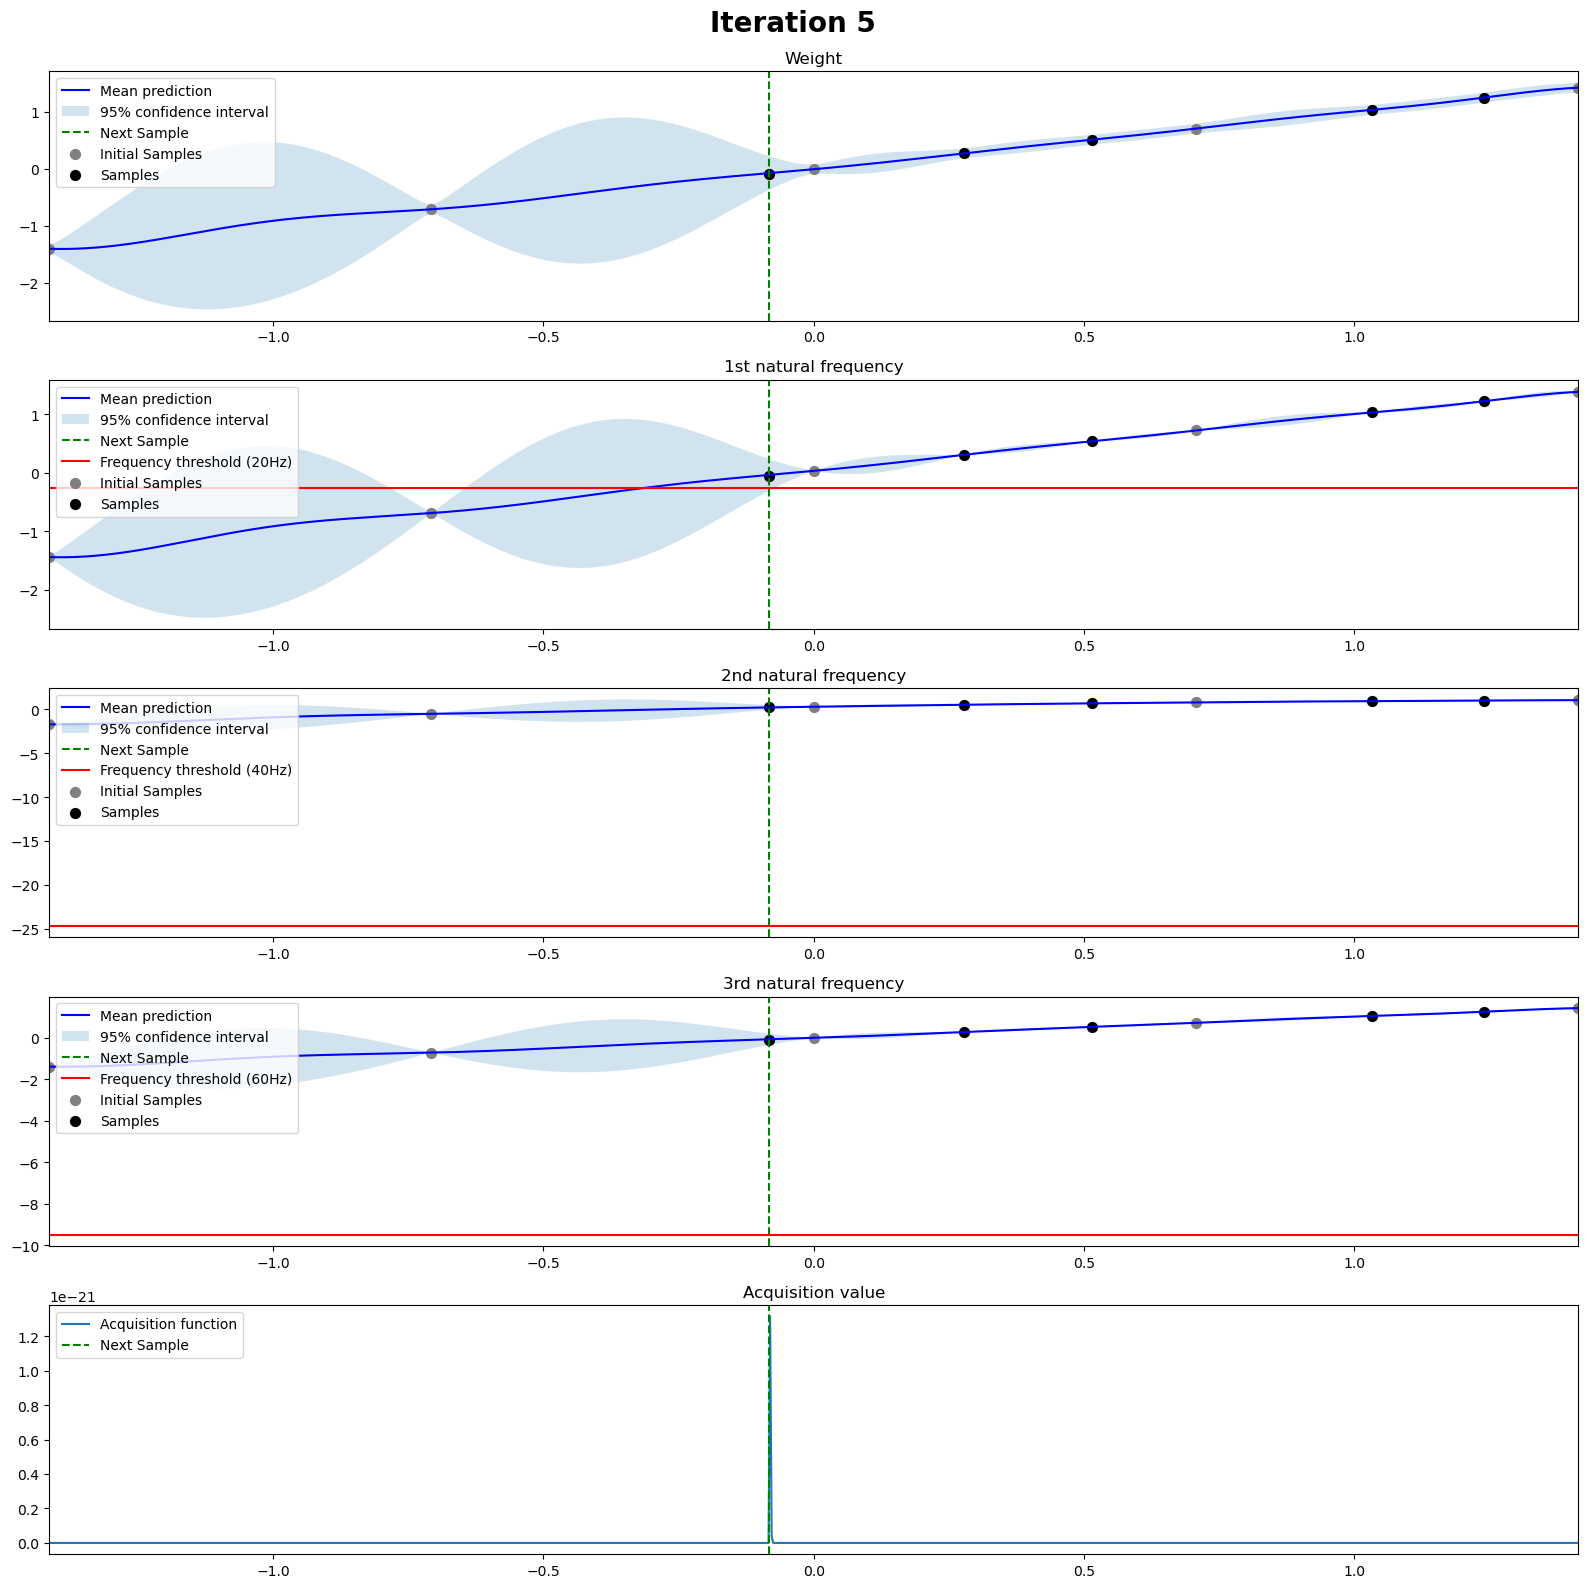

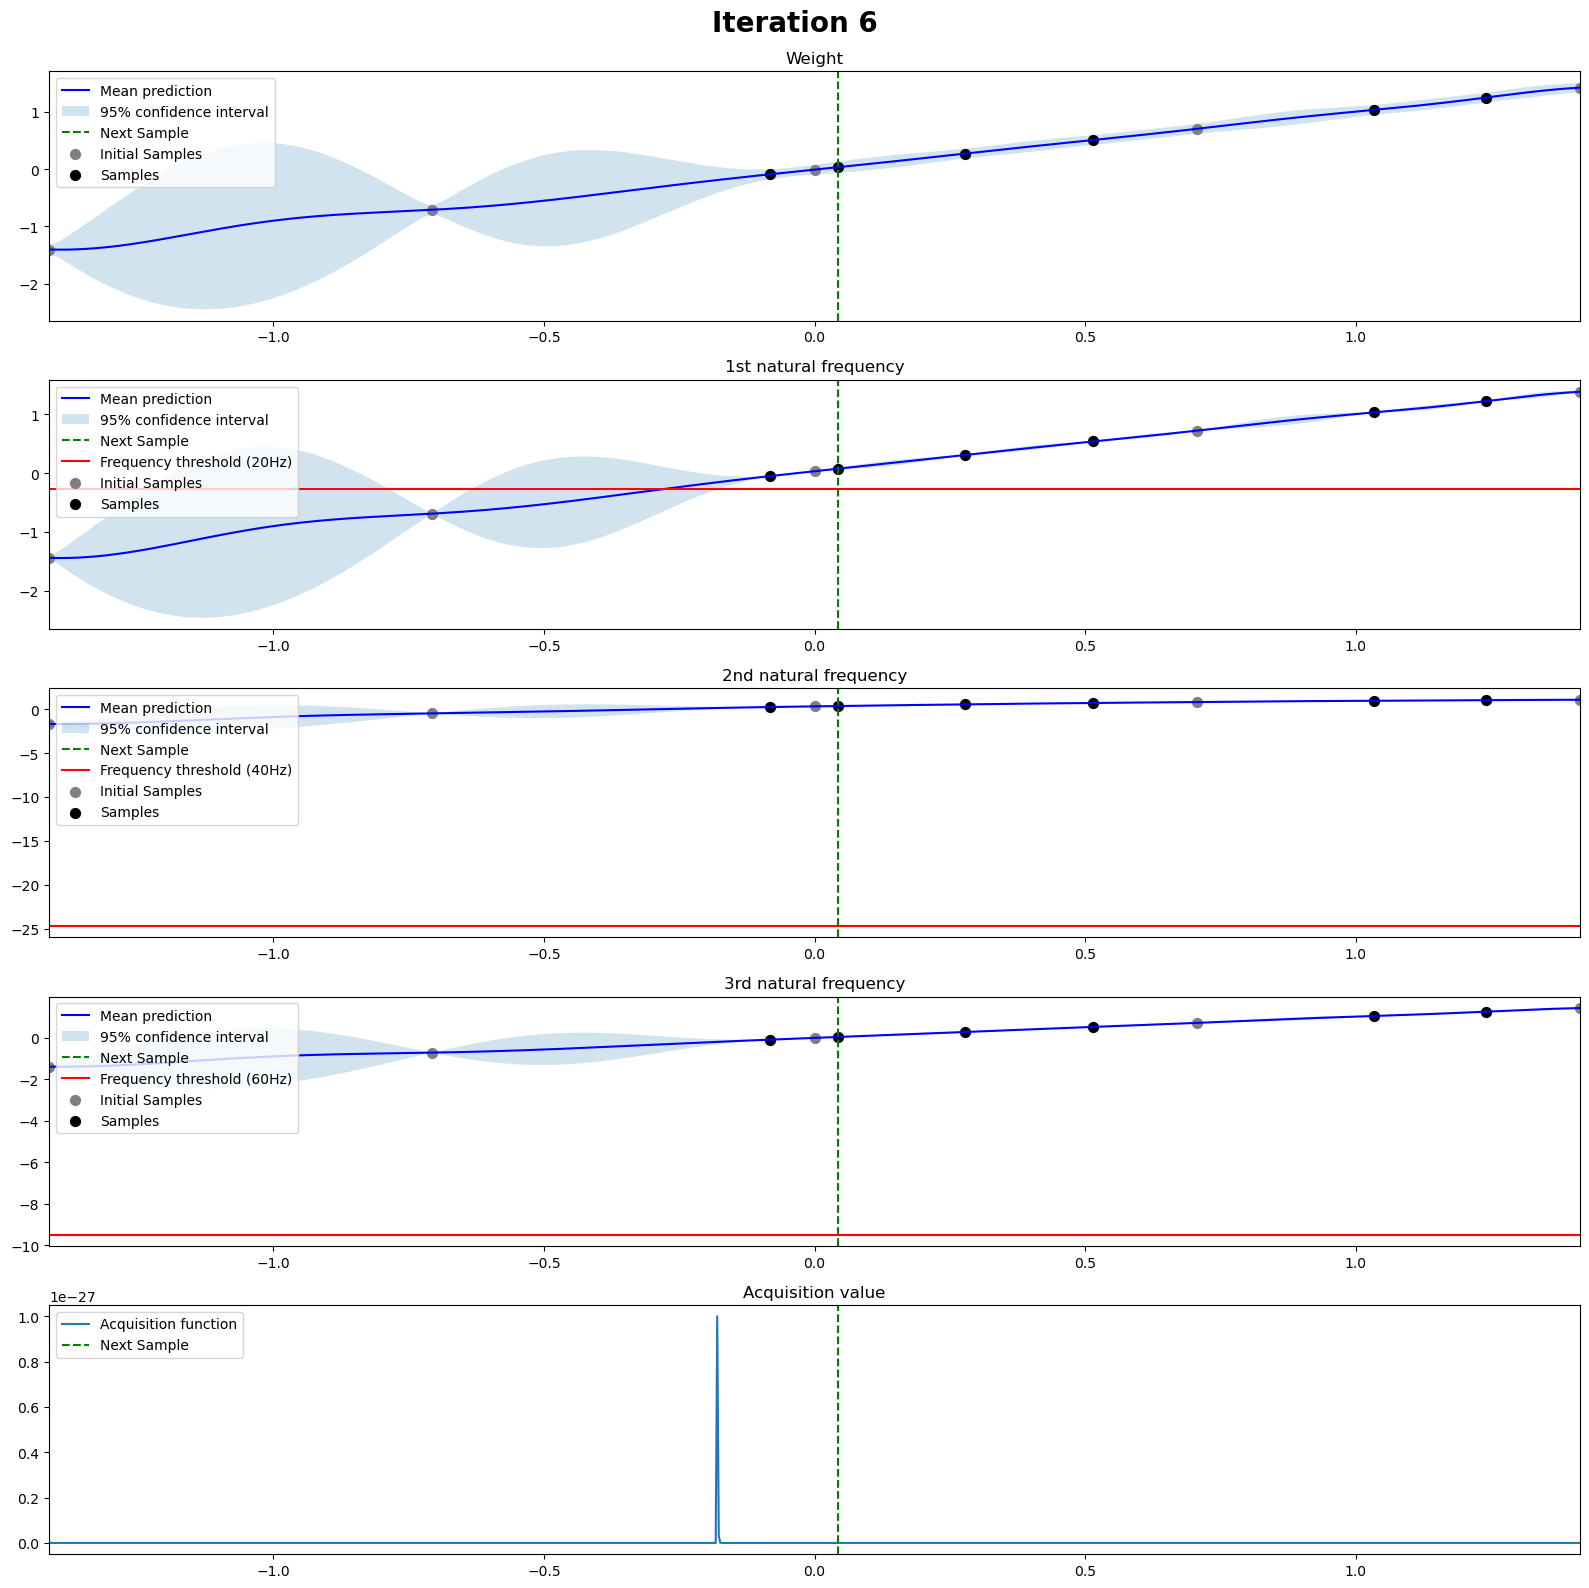

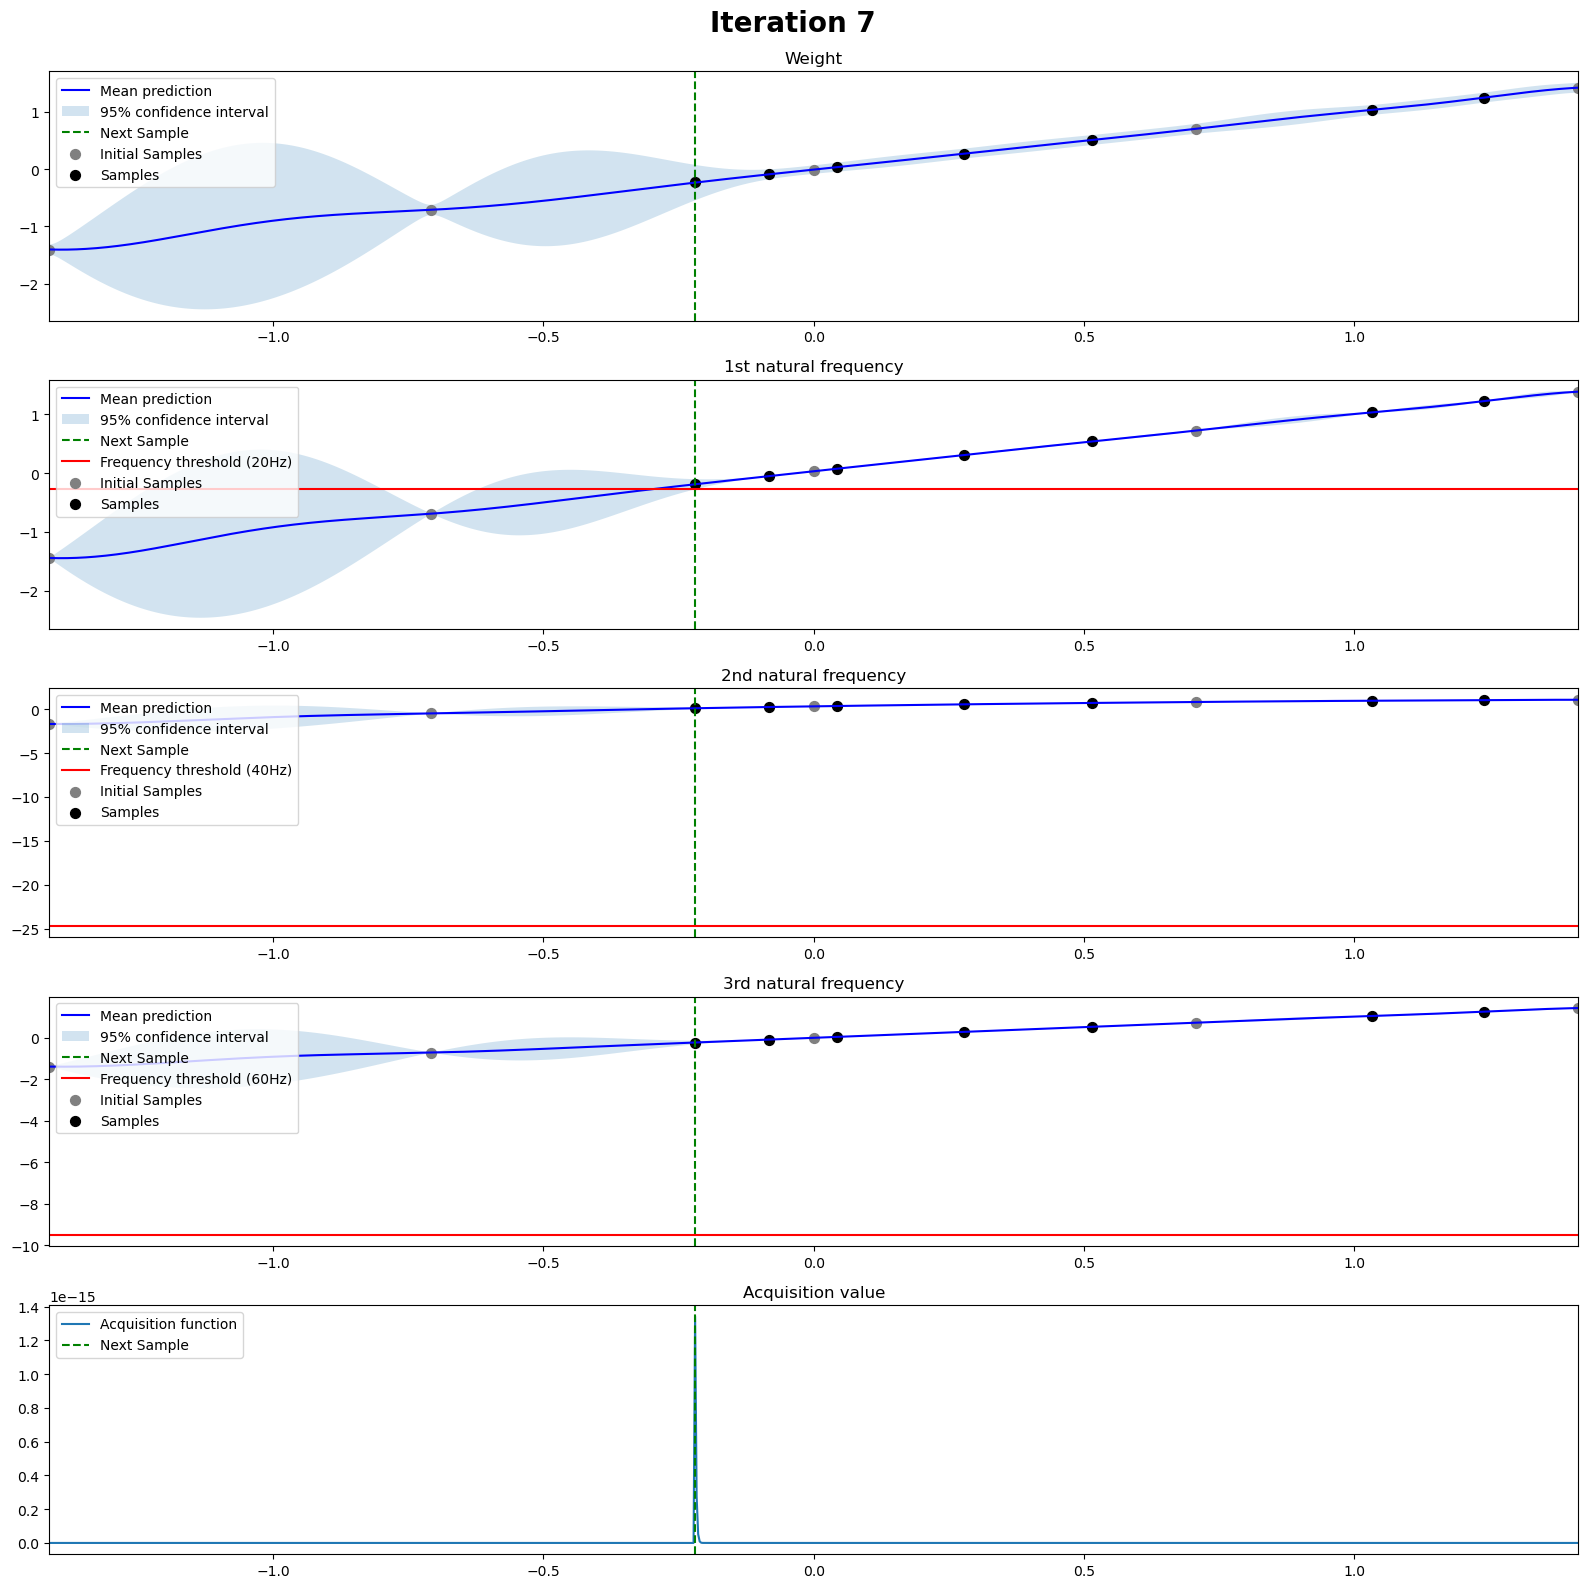

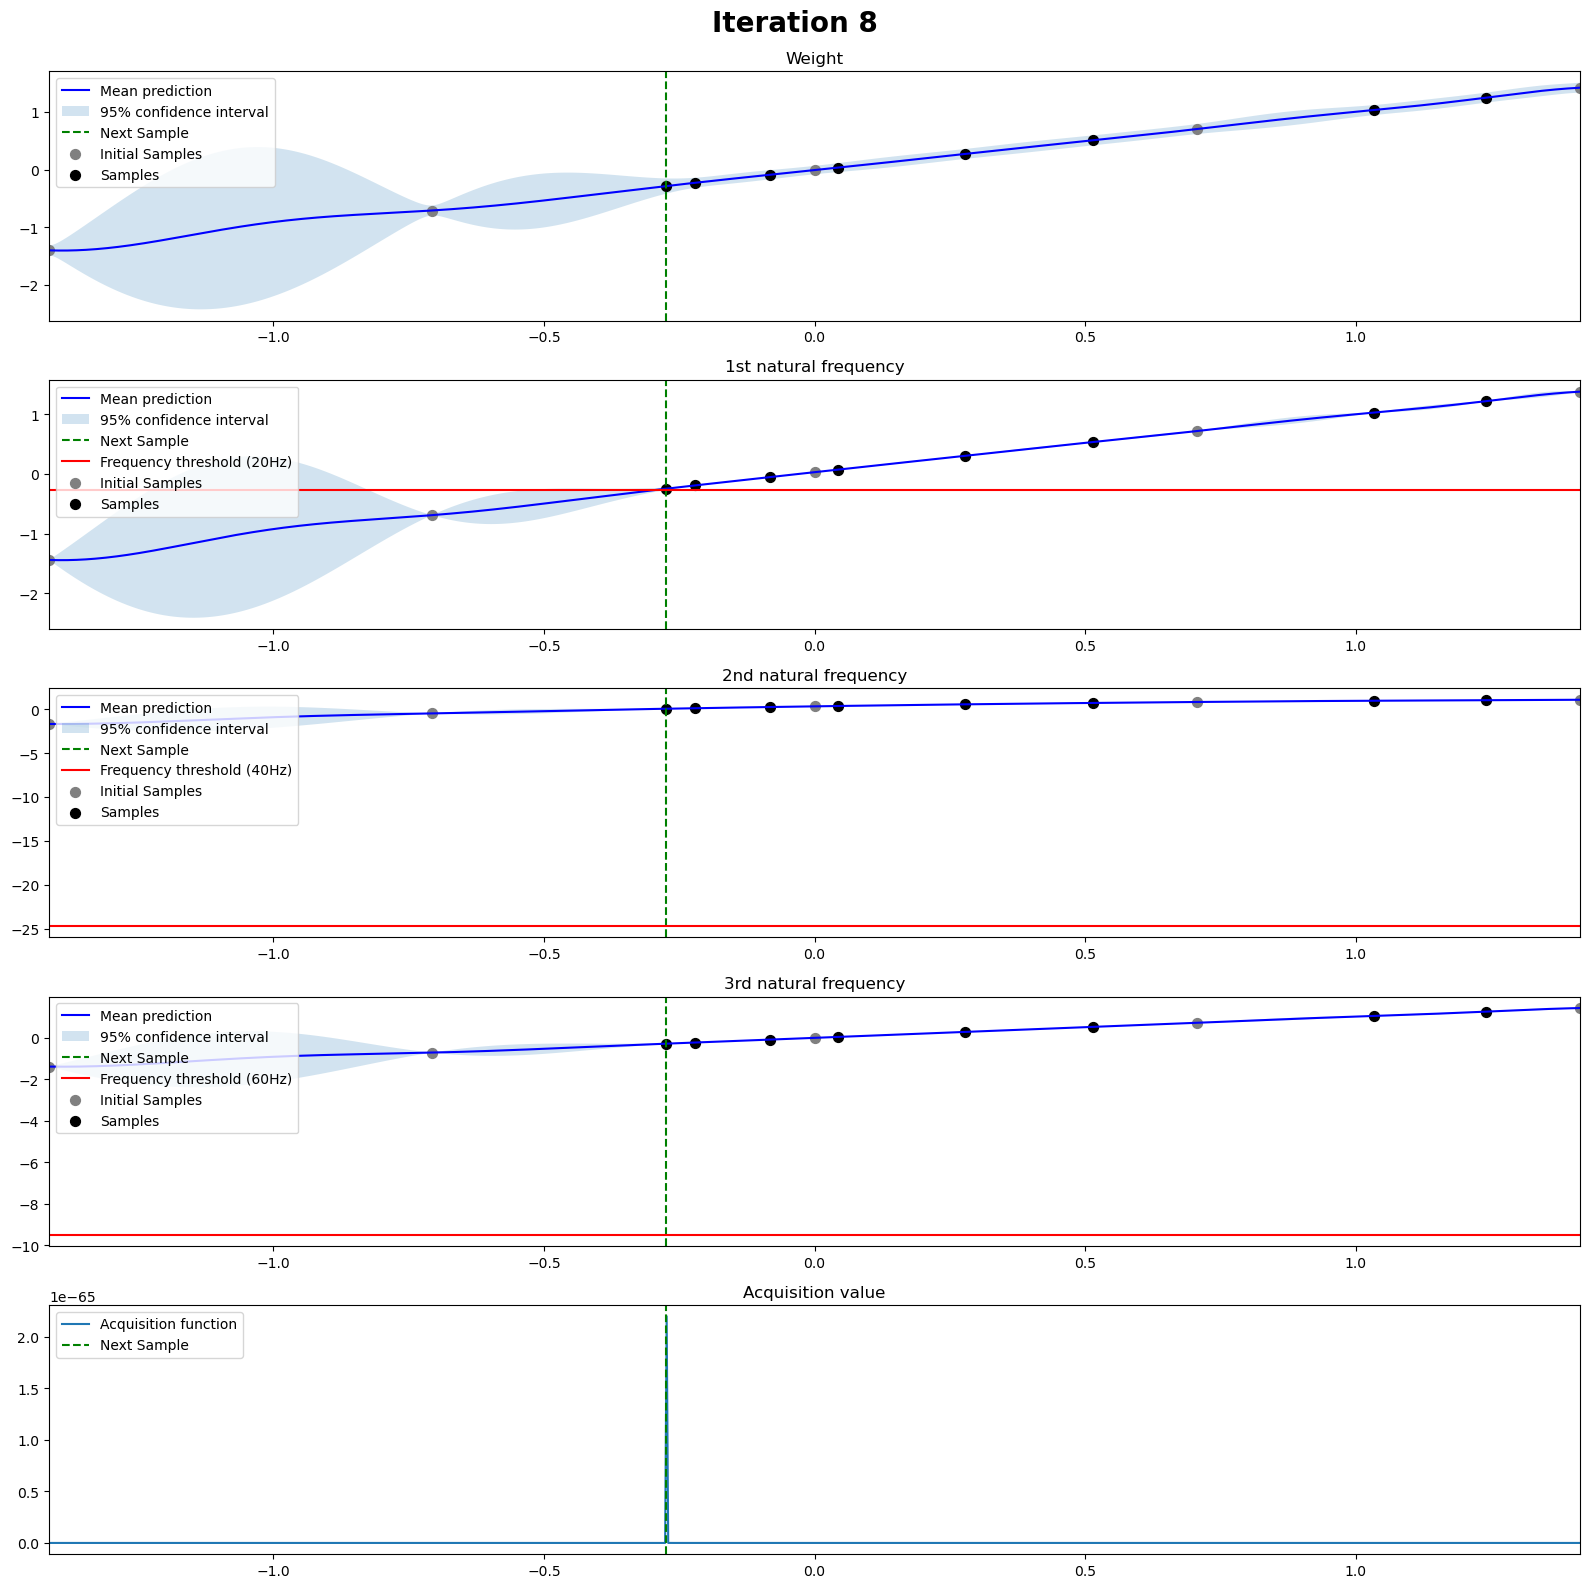

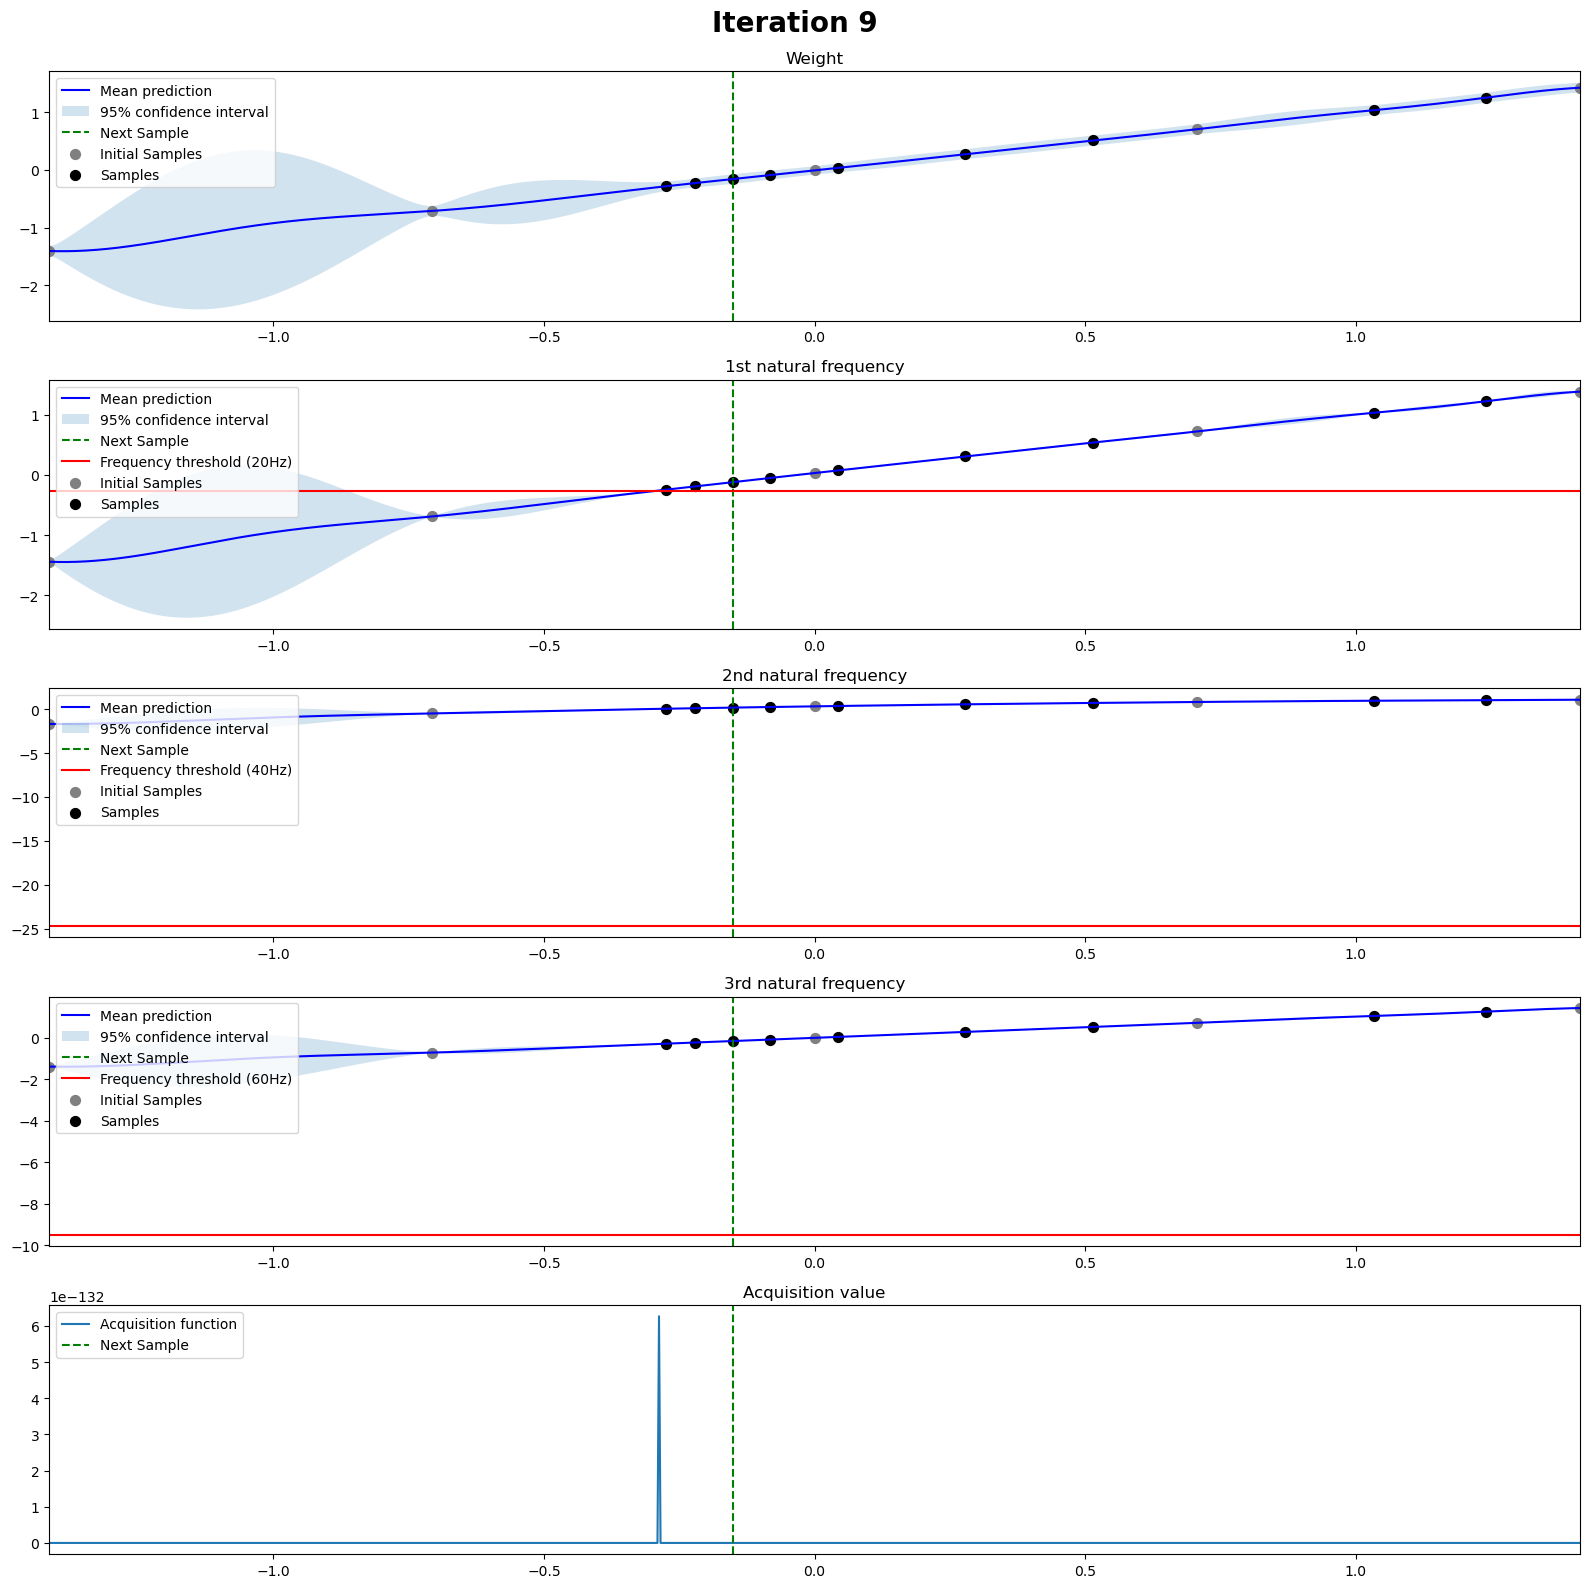

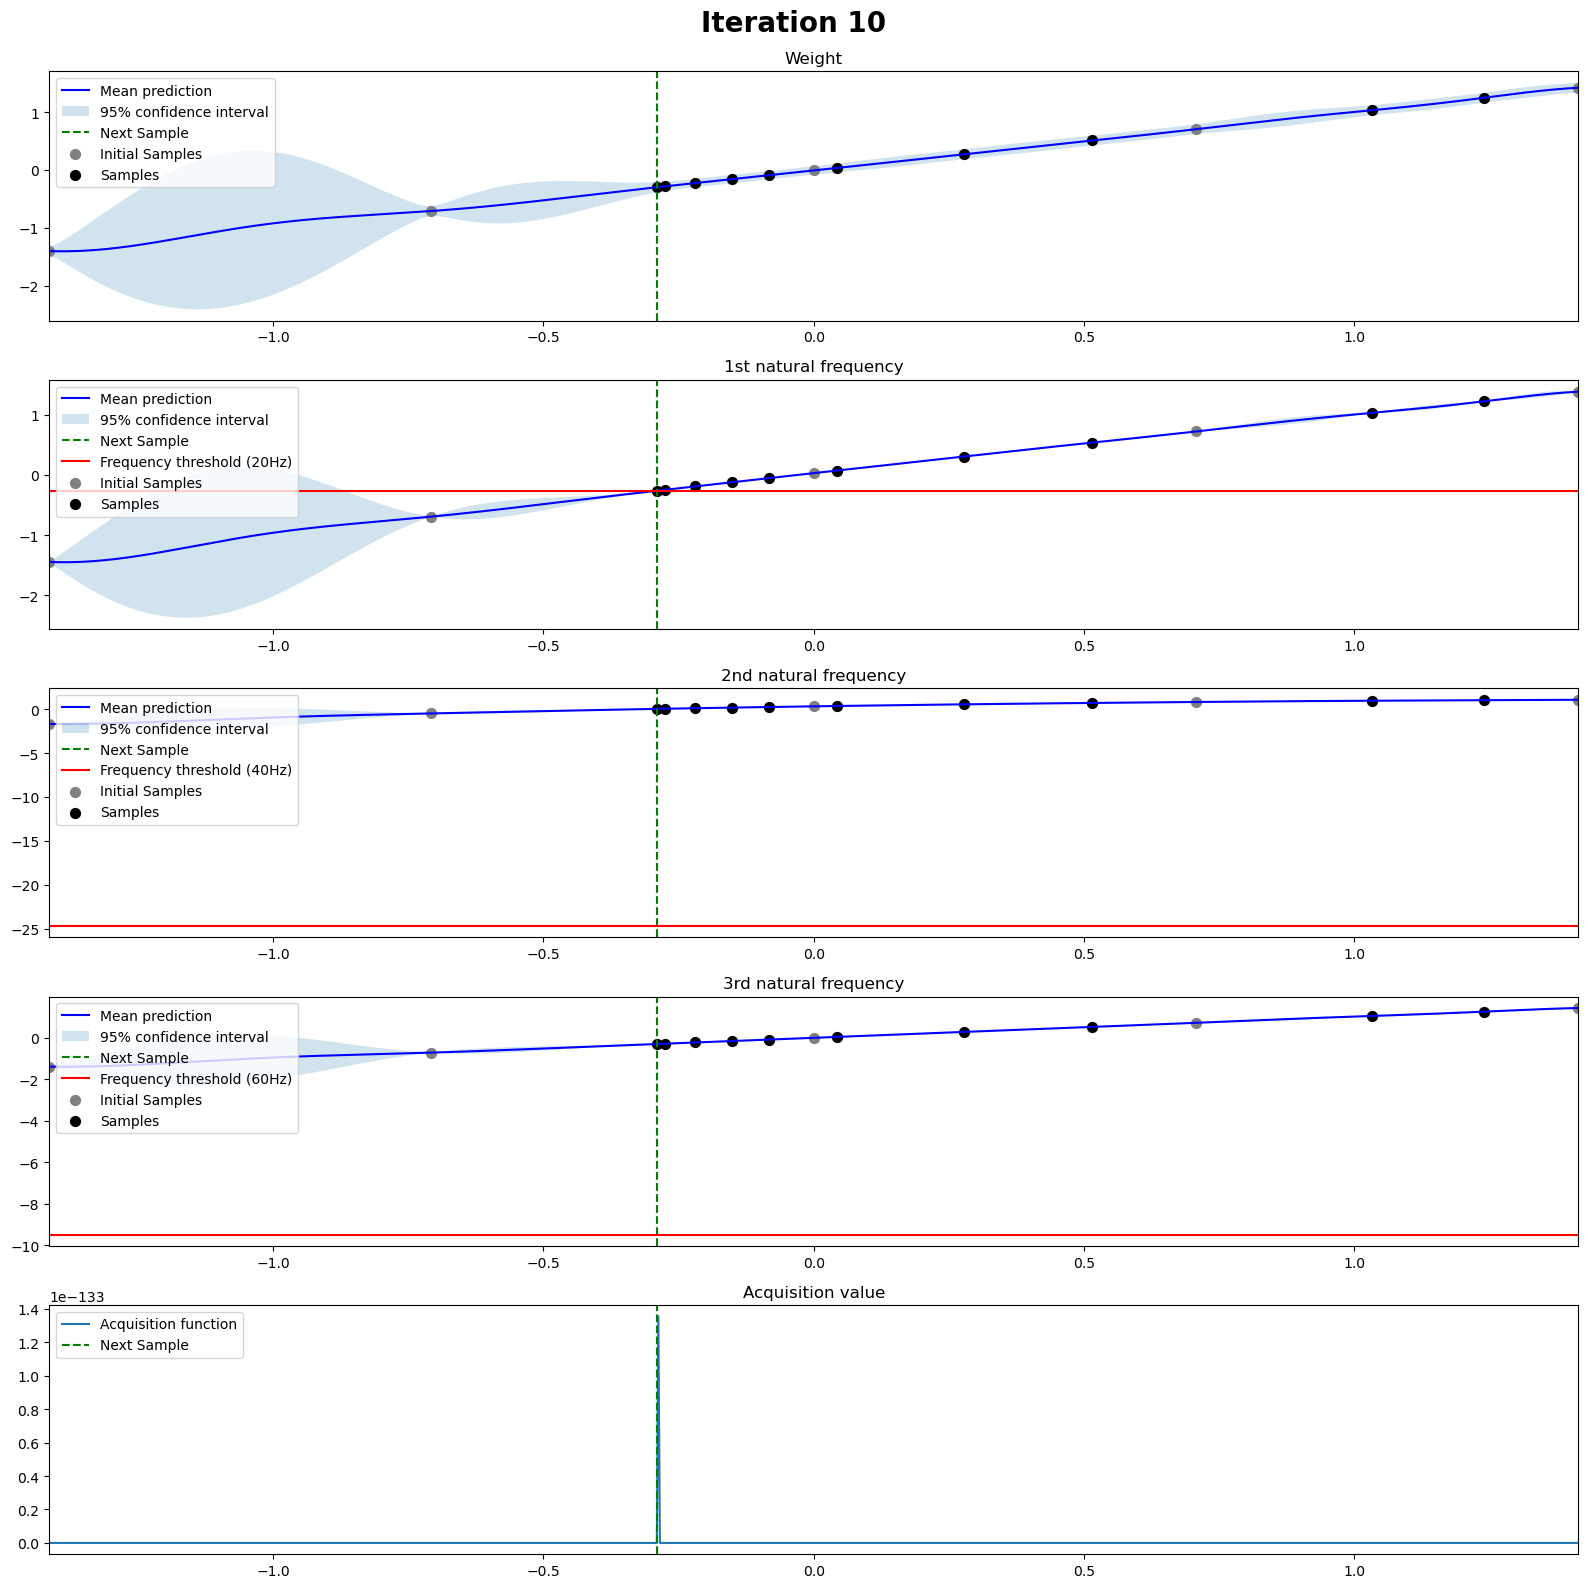

height: 0.8795297530298295
weight: 306.0199139928717
freq1: 20.003786558648986
freq2: 60.52949473499811
freq3: 77.96788440610085


In [33]:
import numpy as np
from scipy.optimize import minimize, differential_evolution
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel, RationalQuadratic, DotProduct
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt

import sys
sys.path.append('../pyJive/')

from utils import proputils as pu
import main
from names import GlobNames as gn
from names import ParamNames as pn

import io
import contextlib


def update_geom_file(geom_path, y_coordinate, update_lines, output_path=None):
    output_path = output_path or geom_path  # Overwrite if no output path provided

    # Read the .geom file
    with open(geom_path, 'r') as file:
        lines = file.readlines()

    # Locate and modify the section with upper node coordinates
    for i in range(len(lines)):
        if i in update_lines:
            parts = lines[i].split()
            parts[-1] = str(y_coordinate)  # Modify the last value
            lines[i] = ' '.join(parts) + '\n'        
            
    # Write back the updated file
    with open(output_path, 'w') as file:
        file.writelines(lines)
        

def finite_element_solver(x):
    x = x[0]
    update_lines = [3, 5, 7 ,9, 11, 13, 15, 17, 19]
    update_geom_file('bridge.geom', x, update_lines, output_path=None)
    
    # Load properties
    props = pu.parse_file('bridge_frequency.pro')

    # Run FEM simulation
    with contextlib.redirect_stdout(io.StringIO()):
        globdat = main.jive(props)

    # Extract mass  
    mass_nodes = props['model']['mass']['nodeGroup']
    n_bottom_nodes = len(globdat[gn.NGROUPS][mass_nodes])
    point_mass = float(props['model']['mass']['mass'])
    weight = 0.5 * np.sum(globdat[pn.MATRIX2]) - n_bottom_nodes * point_mass
    
    # Extract natural frequencies
    freq1 = globdat[gn.EIGENFREQS][0] / (2 * np.pi)
    freq2 = globdat[gn.EIGENFREQS][1] / (2 * np.pi)
    freq3 = globdat[gn.EIGENFREQS][2] / (2 * np.pi)

    return weight, freq1, freq2, freq3


def feasibility_probability(x, gp_freq, threshold):
    '''
    Caculates the probability of the natural frequency being smaller than the minimum required natural frequency (20, 40 or 60).
    This probability is based on the mu and sigma derived from the GP of the corresponding natural frequency.
    Returns True if probability of not fulfilling this constraint is larger than 0.05.
    Returns False if probability of not fulfilling this constraint is smaller than 0.05.
    This give penalized the model if it is not confident in fulfilling the constraint.
    '''
    mu, sigma = gp_freq.predict(x.reshape(1, -1), return_std=True)
    prob = norm.cdf((threshold - mu) / (sigma + 1e-9))
    
    return prob >= 0.05


def EI(x, gp_Y, gp_freq1, gp_freq2, gp_freq3, Y_samples, threshold1, threshold2, threshold3):
    '''
    Based on "Constrained Expected Improvement (CEI)".
    Google it for more info
    '''
    
    '''
    ei is calculated based on a basic acquisition function code (ei).
    Google for better more info
    '''
    mu, sigma = gp_Y.predict(x.reshape(1, -1), return_std=True)
    mu, sigma = mu[0], sigma[0]
    best = np.min(Y_samples)
    
    # Expected Improvement (EI)
    z = (best - mu) / (sigma + 1e-9)
    ei = (best - mu) * norm.cdf(z) + sigma * norm.pdf(z)
    
    '''
    prob describes the "probability" of the natural frequency being larger than the minimum required natural frequency
    prob is either 1 or 0 based on the True or False returned by feasibility_probability()
    1 means the probability of fulfiling the constraint is large. 0 means the opposite.
    These values are then multiplied with the ei enforce the constraints.
    
    Example:
    If the model is NOT confident in fulfilling any of the constraints
    -> feasibility_probability() return True
    -> prob = 0
    -> ei is multiplied by 0
    -> EI = -ei * prob1 * prob2 * prob3 = 0

    If the model is confident in fulfilling any of the constraints
    -> feasibility_probability() return False
    -> prob = 1
    -> ei is multiplied by 1
    -> EI = -ei * prob1 * prob2 * prob3 = -ei
    
    We want to maximize the acquisition function. So we need to minimize the negative of this function.
    '''
    
    prob1 = 1 - feasibility_probability(x, gp_freq1, threshold1)
    prob2 = 1 - feasibility_probability(x, gp_freq2, threshold2)
    prob3 = 1 - feasibility_probability(x, gp_freq3, threshold3)
    
    # print(f"x:, {x}, mu: {mu}, sigma: {sigma}, best: {best}, z: {z}, ei: {ei}, prob1: {prob1}, prob2: {prob2}, prob3: {prob3}")
    
    return -ei * prob1 * prob2 * prob3


def plot(iteration, n_init, gp_Y, gp_freq1, gp_freq2, gp_freq3, x_next, bounds, X_samples, Y_samples, freq1_samples, freq2_samples, freq3_samples, threshold1, threshold2, threshold3):    
    fig, axs = plt.subplots(5, figsize=(16, 16)) 
    fig.suptitle(f"Iteration {iteration+1}", fontsize=20, fontweight='bold', y=0.99)
    X = np.linspace(bounds[0][0], bounds[0][1], 1000).reshape(-1, 1)

    # Plot for Weight
    mu_Y, sigma_Y = gp_Y.predict(X, return_std=True)
    axs[0].plot(X, mu_Y, 'b-', label='Mean prediction')
    axs[0].fill_between(X.ravel(), mu_Y-1.96*sigma_Y, mu_Y+1.96*sigma_Y, alpha=0.2, label='95% confidence interval')   
    axs[0].axvline(x=x_next, color='green', linestyle='--', label="Next Sample")
    axs[0].scatter(X_samples[:n_init], Y_samples[:n_init], c='grey', s=50, zorder=1, label="Initial Samples")
    axs[0].scatter(X_samples[n_init:], Y_samples[n_init:], c='black', s=50, zorder=1, label="Samples")
    axs[0].set_xlim(bounds[0])
    axs[0].set_title('Weight')
    axs[0].legend(loc='upper left')

    # Plot for 1st natural frequency
    mu_freq1, sigma_freq1 = gp_freq1.predict(X, return_std=True)
    axs[1].plot(X, mu_freq1, 'b-', label='Mean prediction')
    axs[1].fill_between(X.ravel(), mu_freq1-1.96*sigma_freq1, mu_freq1+1.96*sigma_freq1, alpha=0.2, label='95% confidence interval')   
    axs[1].axvline(x=x_next, color='green', linestyle='--', label="Next Sample")
    axs[1].axhline(threshold1, color='red', label="Frequency threshold (20Hz)")
    axs[1].scatter(X_samples[:n_init], freq1_samples[:n_init], c='grey', s=50, zorder=1, label="Initial Samples")
    axs[1].scatter(X_samples[n_init:], freq1_samples[n_init:], c='black', s=50, zorder=1, label="Samples")
    axs[1].set_xlim(bounds[0])
    axs[1].set_title('1st natural frequency')
    axs[1].legend(loc='upper left')

    # Plot for 2nd natural frequency
    mu_freq2, sigma_freq2 = gp_freq2.predict(X, return_std=True)
    axs[2].plot(X, mu_freq2, 'b-', label='Mean prediction')
    axs[2].fill_between(X.ravel(), mu_freq2-1.96*sigma_freq2, mu_freq2+1.96*sigma_freq2, alpha=0.2, label='95% confidence interval')   
    axs[2].axvline(x=x_next, color='green', linestyle='--', label="Next Sample")
    axs[2].axhline(threshold2, color='red', label="Frequency threshold (40Hz)")
    axs[2].scatter(X_samples[:n_init], freq2_samples[:n_init], c='grey', s=50, zorder=1, label="Initial Samples")
    axs[2].scatter(X_samples[n_init:], freq2_samples[n_init:], c='black', s=50, zorder=1, label="Samples")
    axs[2].set_xlim(bounds[0])
    axs[2].set_title('2nd natural frequency')
    axs[2].legend(loc='upper left')

    # Plot for 3rd natural frequency
    mu_freq3, sigma_freq3 = gp_freq3.predict(X, return_std=True)
    axs[3].plot(X, mu_freq3, 'b-', label='Mean prediction')
    axs[3].fill_between(X.ravel(), mu_freq3-1.96*sigma_freq3, mu_freq3+1.96*sigma_freq3, alpha=0.2, label='95% confidence interval')   
    axs[3].axvline(x=x_next, color='green', linestyle='--', label="Next Sample")
    axs[3].axhline(threshold3, color='red', label="Frequency threshold (60Hz)")
    axs[3].scatter(X_samples[:n_init], freq3_samples[:n_init], c='grey', s=50, zorder=1, label="Initial Samples")
    axs[3].scatter(X_samples[n_init:], freq3_samples[n_init:], c='black', s=50, zorder=1, label="Samples")
    axs[3].set_xlim(bounds[0])
    axs[3].set_title('3rd natural frequency')
    axs[3].legend(loc='upper left')

    # Plot for acquisition value
    acquisition_value = []
    with contextlib.redirect_stdout(io.StringIO()):
        for x in X:
            acquisition_value.append(-EI(x, gp_Y, gp_freq1, gp_freq2, gp_freq3, Y_samples, threshold1, threshold2, threshold3)[0])
    axs[4].plot(X, acquisition_value, label='Acquisition function')
    axs[4].axvline(x=x_next, color='green', linestyle='--', label="Next Sample")
    axs[4].set_xlim(bounds[0])
    axs[4].set_title('Acquisition value')
    axs[4].legend(loc='upper left')

    plt.tight_layout()
    plt.show()


def bayesian_optimization(n_iter=10):
    '''
    bounds, x values and threshold frequencies are initialized. 
    Based on these x values y (weight) and the nat freqs are derived)
    '''
    # np.random.seed(30)
    n_init = 5
    bounds_unscaled = np.array([[0.8, 1]])
    threshold1_unscaled = 20
    threshold2_unscaled = 40
    threshold3_unscaled = 60
    
    # X_samples_unscaled = np.random.uniform(0.8, 1, size=(n_init, 1))
    X_samples_unscaled = np.linspace(0.8, 1, n_init).reshape(-1, 1) 
    
    output = np.array([finite_element_solver(x) for x in X_samples_unscaled])
    
    Y_samples_unscaled = output[:, 0]
    freq1_samples_unscaled = output[:, 1]
    freq2_samples_unscaled = output[:, 2]
    freq3_samples_unscaled = output[:, 3]
    
    '''
    Everything is scaled. Including the threshold frequencies.
    '''
    input_scaler = StandardScaler()
    output_scaler = StandardScaler()
    freq1_scaler = StandardScaler()
    freq2_scaler = StandardScaler()
    freq3_scaler = StandardScaler()
    
    X_samples = input_scaler.fit_transform(X_samples_unscaled)
    Y_samples = output_scaler.fit_transform(Y_samples_unscaled.reshape(-1, 1)).flatten()
    freq1_samples = freq1_scaler.fit_transform(freq1_samples_unscaled.reshape(-1, 1)).flatten()
    freq2_samples = freq2_scaler.fit_transform(freq2_samples_unscaled.reshape(-1, 1)).flatten()
    freq3_samples = freq3_scaler.fit_transform(freq3_samples_unscaled.reshape(-1, 1)).flatten()
    
    bounds = input_scaler.transform(bounds_unscaled.T).T
    threshold1 = freq1_scaler.transform(np.array(threshold1_unscaled).reshape(-1, 1))[0, 0]
    threshold2 = freq2_scaler.transform(np.array(threshold2_unscaled).reshape(-1, 1))[0, 0]
    threshold3 = freq3_scaler.transform(np.array(threshold3_unscaled).reshape(-1, 1))[0, 0]
    
    '''
    Kernels and GPs are initialized for the weight and the natural frequencies.
    '''
    kernel_Y = RBF(length_scale=0.3) + WhiteKernel(noise_level=1e-3)
    kernel_freq1 = RBF(length_scale=0.3) + WhiteKernel(noise_level=1e-6)
    kernel_freq2 = RBF(length_scale=0.3) + WhiteKernel(noise_level=1e-6)
    kernel_freq3 = RBF(length_scale=0.3) + WhiteKernel(noise_level=1e-6)
    
    gp_Y = GaussianProcessRegressor(kernel=kernel_Y, optimizer=None, alpha=0)
    gp_freq1 = GaussianProcessRegressor(kernel=kernel_freq1, optimizer=None, alpha=0)
    gp_freq2 = GaussianProcessRegressor(kernel=kernel_freq2, optimizer=None, alpha=0)
    gp_freq3 = GaussianProcessRegressor(kernel=kernel_freq3, optimizer=None, alpha=0)
    
    for iteration in range(n_iter):
        '''
        In the first loop, GPs are fit on the inital samples.
        Next loops, GPs are fitted initial samples + next point
        '''
        gp_Y.fit(X_samples, Y_samples)
        gp_freq1.fit(X_samples, freq1_samples)
        gp_freq2.fit(X_samples, freq2_samples)
        gp_freq3.fit(X_samples, freq3_samples)
        
        '''
        It is not possible to minimize the EI() function directly as it has too many input parameters.
        So is is embedded in acquisition(x) which only takes x
        '''
        
        def acquisition(x):
            return EI(x, gp_Y, gp_freq1, gp_freq2, gp_freq3, Y_samples, threshold1, threshold2, threshold3)
        
        '''
        acquisition() is minimized. Different x values are passed to acquisition function.
        The x value that return the smallest value (largest ei*p1*p2*p3), is set as the next x
        x next has to be unscalled before it is passed to the fem solver
        Note in the plots that the next point is elected based on the acquisition value
        '''
        # x_next = minimize(acquisition, np.random.uniform(bounds[0][0], bounds[0][1], 1), bounds=bounds).x
        x_next = differential_evolution(acquisition, bounds=bounds).x
        x_next_unscaled = input_scaler.inverse_transform(x_next.reshape(-1, 1))[0]
        
        '''
        weigth and frequencies are calculated with the fem solver. 
        These values are then scaled
        '''
        y_next_unscaled = finite_element_solver(x_next_unscaled)[0]
        freq1_next_unscaled = finite_element_solver(x_next_unscaled)[1]
        freq2_next_unscaled = finite_element_solver(x_next_unscaled)[2]
        freq3_next_unscaled = finite_element_solver(x_next_unscaled)[3]
        
        y_next = output_scaler.transform(y_next_unscaled.reshape(-1, 1))[0]
        freq1_next = freq1_scaler.transform(freq1_next_unscaled.reshape(-1, 1))[0]
        freq2_next = freq2_scaler.transform(freq2_next_unscaled.reshape(-1, 1))[0]
        freq3_next = freq3_scaler.transform(freq3_next_unscaled.reshape(-1, 1))[0]
        
        '''
        New values are added to the samples
        At the beginning of the next loop the GPs are fit to these updated samples
        '''
        X_samples = np.vstack((X_samples, x_next))
        Y_samples = np.append(Y_samples, y_next)        
        freq1_samples = np.append(freq1_samples, freq1_next)
        freq2_samples = np.append(freq2_samples, freq2_next)
        freq3_samples = np.append(freq3_samples, freq3_next)
        
        plot(iteration, n_init, gp_Y, gp_freq1, gp_freq2, gp_freq3, x_next, bounds, X_samples, Y_samples, freq1_samples, freq2_samples, freq3_samples, threshold1, threshold2, threshold3)
    
    '''
    it could be that the initial values do not fulfull the constraints.
    The index of the valid values is stored.
    The index of the smallest valid y value (weight) is stored
    Samples corresponding to this index are returned
    '''
    valid_idx = np.where((freq1_samples >= threshold1) & (freq2_samples >= threshold2) & (freq3_samples >= threshold3))[0]
    best_idx = valid_idx[np.argmin(Y_samples[valid_idx])]
    best_x_unscaled = input_scaler.inverse_transform(X_samples[best_idx].reshape(-1, 1))[0, 0]
    best_y_unscaled = output_scaler.inverse_transform(Y_samples[best_idx].reshape(-1, 1))[0, 0]
    best_freq1_unscaled = freq1_scaler.inverse_transform(freq1_samples[best_idx].reshape(-1, 1))[0, 0]
    best_freq2_unscaled = freq2_scaler.inverse_transform(freq2_samples[best_idx].reshape(-1, 1))[0, 0]
    best_freq3_unscaled = freq3_scaler.inverse_transform(freq3_samples[best_idx].reshape(-1, 1))[0, 0]
    
    return best_x_unscaled, best_y_unscaled, best_freq1_unscaled, best_freq2_unscaled, best_freq3_unscaled
    
    
height, weight, freq1, freq2, freq3 = bayesian_optimization()
print(f'height: {height}')
print(f'weight: {weight}')
print(f'freq1: {freq1}')
print(f'freq2: {freq2}')
print(f'freq3: {freq3}')